In [82]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score , recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import pickle as pkl


In [83]:
df = pd.read_csv("..\\data\\raw\\water_potability.csv")

df = df.dropna()
df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 2011 entries, 3 to 3271
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2011 non-null   float64
 1   Hardness         2011 non-null   float64
 2   Solids           2011 non-null   float64
 3   Chloramines      2011 non-null   float64
 4   Sulfate          2011 non-null   float64
 5   Conductivity     2011 non-null   float64
 6   Organic_carbon   2011 non-null   float64
 7   Trihalomethanes  2011 non-null   float64
 8   Turbidity        2011 non-null   float64
 9   Potability       2011 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 172.8 KB


In [84]:
X = df.drop("Potability", axis=1)
y = df["Potability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [85]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        eval_metric="logloss"
    )
}



In [86]:
from sklearn.model_selection import GridSearchCV

results = []

for name, model in models.items():
    if name == 'XGBoost':
        params = {
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2],
            "n_estimators": [100, 200]
        }

        grid = GridSearchCV(XGBClassifier(), params, cv=5, scoring="f1")
        grid.fit(X_train, y_train)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # probabilités pour AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = None

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "Recall": recall_score(y_test,y_pred),
        "ROC-AUC": auc
    })

    with open(f'pickle_files\\{name}.pkl', 'wb') as file:
        pkl.dump(model, file)



C:\Users\ilyes\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [87]:

results_df = pd.DataFrame(results)
print(results_df.sort_values(by="F1-score", ascending=False))

                 Model  Accuracy  F1-score    Recall   ROC-AUC
1        Random Forest  0.697270  0.519685  0.404908  0.745181
2              XGBoost  0.655087  0.508834  0.441718  0.669785
0  Logistic Regression  0.595533  0.012121  0.006135  0.504601


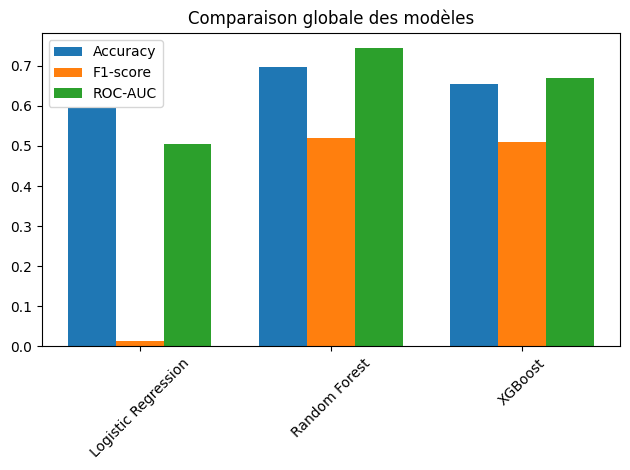

In [88]:
import numpy as np

x = np.arange(len(results_df["Model"]))
width = 0.25

plt.figure()

plt.bar(x - width, results_df["Accuracy"], width, label="Accuracy")
plt.bar(x, results_df["F1-score"], width, label="F1-score")
plt.bar(x + width, results_df["ROC-AUC"], width, label="ROC-AUC")

plt.xticks(x, results_df["Model"], rotation=45)
plt.title("Comparaison globale des modèles")
plt.legend()
plt.tight_layout()
plt.show()